# Capítulo 6 — Redes de Filas com Múltiplas Classes

**Referência:** Seção 6.2 do livro-texto  
**Biblioteca:** `line_solver` — `pfqn_mvamx` (MVA exato para redes mistas)  
**Algoritmo aproximado:** Bard-Schweitzer (implementado manualmente, tolerância = 0,001)

---


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from line_solver.api.pfqn import pfqn_mvamx

STATIONS = ['CPU', 'D1', 'D2']


In [2]:
def amva_mixed(lam, L, N, Z, tol=1e-3, max_iter=500):
    """Bard-Schweitzer AMVA para redes mistas abertas/fechadas.

    Parameters
    ----------
    lam : (R,)   taxas de chegada; 0 para classes fechadas
    L   : (M, R) matriz de demandas de serviço [segundos]
    N   : (R,)   populações; np.inf para classes abertas
    Z   : (R,)   tempos de reflexão [segundos]
    tol : float  tolerância de convergência nos comprimentos de fila (padrão 0.001)

    Returns
    -------
    XN    : (R,)   vazões
    QN    : (M, R) comprimentos médios de fila
    UN    : (M, R) utilizações
    CN    : (M, R) tempos médios de residência por estação
    iters : int    iterações até convergência
    """
    lam, L, N, Z = (np.asarray(x, float) for x in (lam, L, N, Z))
    M, R = L.shape
    is_open = np.isinf(N)

    Q  = np.zeros((M, R))
    XN = np.zeros(R)

    for iters in range(1, max_iter + 1):
        Q_tot = Q.sum(axis=1)          # comprimento total de fila por estação (M,)
        W = np.zeros((M, R))

        for r in range(R):
            if is_open[r]:
                # PASTA: cliente aberto chega e vê a fila em regime estacionário
                W[:, r] = L[:, r] * (1.0 + Q_tot)
            else:
                # Aprox. de Schweitzer: E[Q_i(N-e_r)] ≈ Q_tot - Q[:,r] / N[r]
                W[:, r] = L[:, r] * (1.0 + Q_tot - Q[:, r] / N[r])

        XN_new = np.zeros(R)
        for r in range(R):
            if is_open[r]:
                XN_new[r] = lam[r]
            else:
                XN_new[r] = N[r] / (Z[r] + W[:, r].sum())

        Q_new = XN_new[np.newaxis, :] * W
        delta = np.max(np.abs(Q_new - Q))
        Q, XN = Q_new, XN_new

        if delta < tol:
            break

    UN = XN[np.newaxis, :] * L
    return XN, Q, UN, W, iters


In [3]:
def print_results(label, XN, UN, CN, Z, classes, stations, iters=None):
    """Imprime tabela formatada de resultados MVA."""
    xn = np.ravel(XN)
    R  = len(classes)
    if iters is not None:
        label = label + "  [" + str(iters) + " iter.]"
    sep = "-" * 62
    print()
    print(sep)
    print("  " + label)
    print(sep)
    print(f"{'Classe':<12}  {'X (t/s)':>10}  {'R (s)':>10}  {'C (s)':>10}")
    print("-" * 48)
    for r in range(R):
        R_r = float(CN[:, r].sum())
        C_r = R_r + float(Z[r])
        print(f"{classes[r]:<12}  {float(xn[r]):>10.5f}  {R_r:>10.5f}  {C_r:>10.5f}")
    print()
    u_header = f"{'Estacao':<10}  {'U_total':>8}" + "".join(f"  {'U_'+c:>8}" for c in classes)
    print(u_header)
    print("-" * len(u_header))
    for i, st in enumerate(stations):
        u_tot = float(UN[i, :].sum())
        row = f"{st:<10}  {u_tot:>8.4f}" + "".join(f"  {float(UN[i, r]):>8.4f}" for r in range(R))
        print(row)
    print()


---
## Questão 1 — Modelo da Seção 6.2: AMVA vs. MVA Exato

Modelo **fechado** com **3 estações** (CPU, D1, D2) e **2 classes** (Tabela 6.1 do livro):

| Classe | Tipo | Parâmetros | $[D_{CPU},\ D_{D1},\ D_{D2}]$ (s) |
|--------|------|-----------|--------------------------------------|
| Q (query) | Fechada batch | $N_Q = 3$ | $[0{,}105,\ 0{,}180,\ 0{,}000]$ |
| U (update) | Fechada batch | $N_U = 1$ (original) / $N_U = 3$ (triplicado) | $[0{,}375,\ 0{,}480,\ 0{,}240]$ |

Mix original: 3 queries + 1 update = 4 transações em memória simultaneamente (modelo puramente fechado, sem chegadas externas).  
Compara-se o **Bard-Schweitzer** (aproximado, tolerância 0,001) com o **MVA exato** (`pfqn_mvamx`).


In [4]:
# Tabela 6.1 — Seção 6.2 (demandas em segundos)
L2 = np.array([[0.105, 0.375],   # CPU: D_Q = 105 ms, D_U = 375 ms
               [0.180, 0.480],   # D1:  D_Q = 180 ms, D_U = 480 ms
               [0.000, 0.240]])  # D2:  D_Q =   0 ms, D_U = 240 ms

lam2 = np.array([0.0, 0.0])     # ambas fechadas (sem chegadas externas)
Z2   = np.array([0.0, 0.0])     # batch: sem tempo de reflexao
CL2  = ['Q', 'U']


In [5]:
# ── N_Q=3, N_U=1 (mix original: 3 queries + 1 update) ────────────────────────
N2_orig = np.array([3.0, 1.0])

# Bard-Schweitzer aproximado (tol = 0.001) — funciona para redes puramente fechadas
XN_a1, _, UN_a1, CN_a1, it_a1 = amva_mixed(lam2, L2, N2_orig, Z2, tol=1e-3)
print_results("N=[3,1] | Bard-Schweitzer AMVA (tol=0.001)",
              XN_a1, UN_a1, CN_a1, Z2, CL2, STATIONS, iters=it_a1)

# MVA exato
XN_e1, _, UN_e1, CN_e1, _ = pfqn_mvamx(lam2, L2, N2_orig, Z2)
print_results("N=[3,1] | MVA exato (pfqn_mvamx)",
              XN_e1, UN_e1, CN_e1, Z2, CL2, STATIONS)



--------------------------------------------------------------
  N=[3,1] | Bard-Schweitzer AMVA (tol=0.001)  [10 iter.]
--------------------------------------------------------------
Classe           X (t/s)       R (s)       C (s)
------------------------------------------------
Q                3.99688     0.75059     0.75059
U                0.40692     2.45747     2.45747

Estacao      U_total       U_Q       U_U
----------------------------------------
CPU           0.5723    0.4197    0.1526
D1            0.9148    0.7194    0.1953
D2            0.0977    0.0000    0.0977


--------------------------------------------------------------
  N=[3,1] | MVA exato (pfqn_mvamx)
--------------------------------------------------------------
Classe           X (t/s)       R (s)       C (s)
------------------------------------------------
Q                4.09389     0.73280     0.73280
U                0.40933     2.44300     2.44300

Estacao      U_total       U_Q       U_U
-------------

In [6]:
# ── N_Q=3, N_U=3 (N_U triplicado) ────────────────────────────────────────────
N2_trip = np.array([3.0, 3.0])

# Bard-Schweitzer aproximado (tol = 0.001)
XN_a3, _, UN_a3, CN_a3, it_a3 = amva_mixed(lam2, L2, N2_trip, Z2, tol=1e-3)
print_results("N=[3,3] | Bard-Schweitzer AMVA (tol=0.001)",
              XN_a3, UN_a3, CN_a3, Z2, CL2, STATIONS, iters=it_a3)

# MVA exato
XN_e3, _, UN_e3, CN_e3, _ = pfqn_mvamx(lam2, L2, N2_trip, Z2)
print_results("N=[3,3] | MVA exato (pfqn_mvamx)",
              XN_e3, UN_e3, CN_e3, Z2, CL2, STATIONS)

states_orig = (int(N2_orig[0]) + 1) * (int(N2_orig[1]) + 1)
states_trip = (int(N2_trip[0]) + 1) * (int(N2_trip[1]) + 1)
print(f"Iteracoes AMVA:       N_U=1 -> {it_a1}   |   N_U=3 -> {it_a3}")
print(f"Estados (MVA exato):  N_U=1 -> {states_orig}      |   N_U=3 -> {states_trip}")



--------------------------------------------------------------
  N=[3,3] | Bard-Schweitzer AMVA (tol=0.001)  [13 iter.]
--------------------------------------------------------------
Classe           X (t/s)       R (s)       C (s)
------------------------------------------------
Q                2.84614     1.05406     1.05406
U                0.89889     3.33744     3.33744

Estacao      U_total       U_Q       U_U
----------------------------------------
CPU           0.6359    0.2988    0.3371
D1            0.9438    0.5123    0.4315
D2            0.2157    0.0000    0.2157


--------------------------------------------------------------
  N=[3,3] | MVA exato (pfqn_mvamx)
--------------------------------------------------------------
Classe           X (t/s)       R (s)       C (s)
------------------------------------------------
Q                2.93810     1.02107     1.02107
U                0.90645     3.30963     3.30963

Estacao      U_total       U_Q       U_U
-------------

### Análise do Esforço Computacional

| Algoritmo | Complexidade | Escala com $N_U$? |
|-----------|-------------|-------------------|
| **Bard-Schweitzer** | $O(\text{iter} \times M \times R)$ | Não significativamente |
| **MVA exato (fechado)** | $O\!\left(\prod_r(N_r{+}1) \times M \times R\right)$ | Sim, **multiplicativa** |

- **AMVA**: itera até $\max_{i,r}|\Delta Q_{i,r}| < 0{,}001$ — o número de iterações cresce lentamente com a população.  
- **MVA exato**: percorre todos os vetores de população $\{(n_Q, n_U) : n_Q \leq N_Q,\, n_U \leq N_U\}$. Triplicar $N_U$ (de 1 para 3) dobra os estados de **8 para 16**.  
- **Conclusão**: AMVA é computacionalmente vantajoso quando as populações são grandes, pois o espaço de estados do MVA exato cresce como produto das populações.


---
## Questão 2 — Mover Carga de E/S de Query para Disk 2

O texto da Seção 6.2 levanta a questão: *"Disk 1 é o gargalo e Disk 2 está levemente carregado — qual seria o tempo de resposta se toda a carga de E/S de query fosse movida para Disk 2?"*

| Cenário | $D_{D1,Q}$ | $D_{D2,Q}$ | Total E/S de Q |
|---------|-----------|-----------|---------------|
| Original | 180 ms | 0 ms | 180 ms |
| Modificado | 0 ms | 180 ms | 180 ms |

Avalia-se o impacto no throughput, utilização das estações e tempo de resposta (modelo com $N = [3, 1]$).


In [7]:
# Q2: Mover toda a carga de E/S de query do D1 para o D2  (N=[3,1])
L2_mod       = L2.copy()
L2_mod[1, 0] = 0.000   # D1, classe Q: 180 ms -> 0
L2_mod[2, 0] = 0.180   # D2, classe Q:   0 ms -> 180 ms

XN_o, _, UN_o, CN_o, _ = pfqn_mvamx(lam2, L2,     N2_orig, Z2)
XN_m, _, UN_m, CN_m, _ = pfqn_mvamx(lam2, L2_mod, N2_orig, Z2)

print_results("Q2 — Original        (D_D1_Q=180 ms, D_D2_Q=  0 ms)",
              XN_o, UN_o, CN_o, Z2, CL2, STATIONS)
print_results("Q2 — E/S movida D2   (D_D1_Q=  0 ms, D_D2_Q=180 ms)",
              XN_m, UN_m, CN_m, Z2, CL2, STATIONS)

R_Q_o = float(CN_o[:, 0].sum())
R_Q_m = float(CN_m[:, 0].sum())
R_U_o = float(CN_o[:, 1].sum())
R_U_m = float(CN_m[:, 1].sum())
print(f"Tempo de resposta Q:  original = {R_Q_o:.5f} s   modificado = {R_Q_m:.5f} s   variacao = {(R_Q_m/R_Q_o - 1)*100:+.2f}%")
print(f"Tempo de resposta U:  original = {R_U_o:.5f} s   modificado = {R_U_m:.5f} s   variacao = {(R_U_m/R_U_o - 1)*100:+.2f}%")



--------------------------------------------------------------
  Q2 — Original        (D_D1_Q=180 ms, D_D2_Q=  0 ms)
--------------------------------------------------------------
Classe           X (t/s)       R (s)       C (s)
------------------------------------------------
Q                4.09389     0.73280     0.73280
U                0.40933     2.44300     2.44300

Estacao      U_total       U_Q       U_U
----------------------------------------
CPU           0.5834    0.4299    0.1535
D1            0.9334    0.7369    0.1965
D2            0.0982    0.0000    0.0982


--------------------------------------------------------------
  Q2 — E/S movida D2   (D_D1_Q=  0 ms, D_D2_Q=180 ms)
--------------------------------------------------------------
Classe           X (t/s)       R (s)       C (s)
------------------------------------------------
Q                4.33368     0.69225     0.69225
U                0.51725     1.93329     1.93329

Estacao      U_total       U_Q       U

---
## Questão 3 — Modelo com 3 Classes (Q + U + I)

| Classe | Tipo | Parâmetros | $[D_{CPU},\ D_{D1},\ D_{D2}]$ (s) |
|--------|------|-----------|--------------------------------------|
| Q | Aberta | $\lambda_Q = 3{,}0$ t/s | $[0{,}060,\ 0{,}030,\ 0{,}000]$ |
| U | Fechada batch | $N_U = 3$ | $[0{,}100,\ 0{,}030,\ 0{,}093]$ |
| I | Interativa | $M_I = 50$ terminais, $Z_I = 15$ s | $[0{,}090,\ 0{,}045,\ 0{,}005]$ |


In [8]:
# Parâmetros Q3 — modelo 3 classes
L3 = np.array([[0.060, 0.100, 0.090],   # CPU
               [0.030, 0.030, 0.045],   # D1
               [0.000, 0.093, 0.005]])  # D2

lam3 = np.array([3.0,    0.0,  0.0])    # Q: aberta; U, I: fechadas
N3   = np.array([np.inf, 3.0, 50.0])    # N_U=3, M_I=50
Z3   = np.array([0.0,    0.0, 15.0])    # Z_I = 15 s
M_I  = 50
CL3  = ['Q', 'U', 'I']


### 3a — Tempos de Resposta por Classe (cenário base, $\lambda_Q = 3{,}0$ t/s)


In [9]:
# 3a: modelo base
XN3a, _, UN3a, CN3a, _ = pfqn_mvamx(lam3, L3, N3, Z3)
xn3a = np.ravel(XN3a)

R_Q_a = float(CN3a[:, 0].sum())           # soma dos tempos de residencia
R_U_a = float(CN3a[:, 1].sum())           # ciclo batch (Z_U=0)
R_I_a = float(M_I / xn3a[2] - Z3[2])     # R_I = M_I/X_I - Z_I

print_results("Q3a — Modelo 3 classes (base, lambda_Q=3.0 t/s)",
              XN3a, UN3a, CN3a, Z3, CL3, STATIONS)
print("Tempos de resposta por classe:")
print(f"  R_Q = {R_Q_a:.5f} s  (aberta: soma dos tempos de residencia)")
print(f"  R_U = {R_U_a:.5f} s  (batch:  C_U = N_U/X_U = {3.0/xn3a[1]:.5f} s, Z_U=0)")
print(f"  R_I = {R_I_a:.5f} s  (interativo: M_I/X_I - Z_I = {M_I}/{xn3a[2]:.5f} - {int(Z3[2])})")



--------------------------------------------------------------
  Q3a — Modelo 3 classes (base, lambda_Q=3.0 t/s)
--------------------------------------------------------------
Classe           X (t/s)       R (s)       C (s)
------------------------------------------------
Q                3.00000     0.39292     0.39292
U                4.83935     0.61992     0.61992
I                3.20698     0.59101    15.59101

Estacao      U_total       U_Q       U_U       U_I
--------------------------------------------------
CPU           0.9526    0.1800    0.4839    0.2886
D1            0.3795    0.0900    0.1452    0.1443
D2            0.4661    0.0000    0.4501    0.0160

Tempos de resposta por classe:
  R_Q = 0.39292 s  (aberta: soma dos tempos de residencia)
  R_U = 0.61992 s  (batch:  C_U = N_U/X_U = 0.61992 s, Z_U=0)
  R_I = 0.59101 s  (interativo: M_I/X_I - Z_I = 50/3.20698 - 15)


### 3b — Aumento de $\lambda_Q$ em 95% ($\lambda_Q = 5{,}85$ t/s)


In [10]:
# 3b: lambda_Q aumentada 95%
lam3b    = lam3.copy()
lam3b[0] = lam3[0] * 1.95   # 3.0 x 1.95 = 5.85 t/s

XN3b, _, UN3b, CN3b, _ = pfqn_mvamx(lam3b, L3, N3, Z3)
xn3b = np.ravel(XN3b)

R_Q_b = float(CN3b[:, 0].sum())
R_U_b = float(CN3b[:, 1].sum())
R_I_b = float(M_I / xn3b[2] - Z3[2])

print_results(f"Q3b — lambda_Q = {lam3b[0]:.2f} t/s (+95%)",
              XN3b, UN3b, CN3b, Z3, CL3, STATIONS)
print("Comparacao dos tempos de resposta (base -> +95%):")
print(f"  R_Q: {R_Q_a:.5f} -> {R_Q_b:.5f} s   delta = {R_Q_b - R_Q_a:+.5f} s  ({(R_Q_b/R_Q_a-1)*100:+.1f}%)")
print(f"  R_U: {R_U_a:.5f} -> {R_U_b:.5f} s   delta = {R_U_b - R_U_a:+.5f} s  ({(R_U_b/R_U_a-1)*100:+.1f}%)")
print(f"  R_I: {R_I_a:.5f} -> {R_I_b:.5f} s   delta = {R_I_b - R_I_a:+.5f} s  ({(R_I_b/R_I_a-1)*100:+.1f}%)")



--------------------------------------------------------------
  Q3b — lambda_Q = 5.85 t/s (+95%)
--------------------------------------------------------------
Classe           X (t/s)       R (s)       C (s)
------------------------------------------------
Q                5.85000     0.59673     0.59673
U                3.51223     0.85416     0.85416
I                3.14692     0.88853    15.88853

Estacao      U_total       U_Q       U_U       U_I
--------------------------------------------------
CPU           0.9854    0.3510    0.3512    0.2832
D1            0.4225    0.1755    0.1054    0.1416
D2            0.3424    0.0000    0.3266    0.0157

Comparacao dos tempos de resposta (base -> +95%):
  R_Q: 0.39292 -> 0.59673 s   delta = +0.20381 s  (+51.9%)
  R_U: 0.61992 -> 0.85416 s   delta = +0.23424 s  (+37.8%)
  R_I: 0.59101 -> 0.88853 s   delta = +0.29752 s  (+50.3%)


### 3c — Comparação de Melhorias de Hardware (a partir de 3b)

Dois upgrades avaliados com $\lambda_Q = 5{,}85$ t/s:

1. **D1 2× mais rápido**: $D_{D1,r} \leftarrow D_{D1,r}/2$ para todas as classes  
2. **CPU 2× mais rápida**: $D_{CPU,r} \leftarrow D_{CPU,r}/2$ para todas as classes


In [11]:
# 3c: upgrades de hardware (a partir do cenario 3b)
L3_fastD1  = L3.copy(); L3_fastD1[1, :]  /= 2.0   # D1 duas vezes mais rapido
L3_fastCPU = L3.copy(); L3_fastCPU[0, :] /= 2.0   # CPU duas vezes mais rapida

# Upgrade 1: D1 mais rapido
XN_d1, _, UN_d1, CN_d1, _ = pfqn_mvamx(lam3b, L3_fastD1,  N3, Z3)
xn_d1  = np.ravel(XN_d1)
R_I_d1 = float(M_I / xn_d1[2] - Z3[2])

# Upgrade 2: CPU mais rapida
XN_cp, _, UN_cp, CN_cp, _ = pfqn_mvamx(lam3b, L3_fastCPU, N3, Z3)
xn_cp  = np.ravel(XN_cp)
R_I_cp = float(M_I / xn_cp[2] - Z3[2])

print_results("Q3c — D1 2x mais rapido   (lambda_Q=5.85 t/s)",
              XN_d1, UN_d1, CN_d1, Z3, CL3, STATIONS)
print(f"  R_I = {R_I_d1:.5f} s   (delta vs. 3b: {R_I_d1 - R_I_b:+.5f} s)")
print()

print_results("Q3c — CPU 2x mais rapida  (lambda_Q=5.85 t/s)",
              XN_cp, UN_cp, CN_cp, Z3, CL3, STATIONS)
print(f"  R_I = {R_I_cp:.5f} s   (delta vs. 3b: {R_I_cp - R_I_b:+.5f} s)")
print()

melhor = "D1 mais rapido" if R_I_d1 < R_I_cp else "CPU mais rapida"
print(f"-> Melhor upgrade: {melhor}  (R_I = {min(R_I_d1, R_I_cp):.5f} s)")



--------------------------------------------------------------
  Q3c — D1 2x mais rapido   (lambda_Q=5.85 t/s)
--------------------------------------------------------------
Classe           X (t/s)       R (s)       C (s)
------------------------------------------------
Q                5.85000     0.58137     0.58137
U                3.54355     0.84661     0.84661
I                3.15151     0.86543    15.86543

Estacao      U_total       U_Q       U_U       U_I
--------------------------------------------------
CPU           0.9890    0.3510    0.3544    0.2836
D1            0.2118    0.0877    0.0532    0.0709
D2            0.3453    0.0000    0.3296    0.0158

  R_I = 0.86543 s   (delta vs. 3b: -0.02310 s)


--------------------------------------------------------------
  Q3c — CPU 2x mais rapida  (lambda_Q=5.85 t/s)
--------------------------------------------------------------
Classe           X (t/s)       R (s)       C (s)
------------------------------------------------
Q 

### 3d — Tempo de Resposta Interativo vs. Número de Terminais

Varredura de $M_I \in [50, 300]$ com $\lambda_Q = 5{,}85$ t/s e **CPU 2× mais rápida**.  
Objetivo: determinar o **máximo $M_I$** tal que $R_I < 1{,}5$ s.

> **Nota:** `pfqn_mvamx` usa o fatorial exato para o cálculo da constante de normalização, o que causa *overflow* numérico para $M_I \geq 180$ (o `float64` não representa $180!$). Para a varredura com populações grandes, usa-se o algoritmo de Bard-Schweitzer (`amva_mixed`), que é a escolha natural nesses cenários.


Maximo de terminais com R_I < 1.5 s:  M_I_max = 250


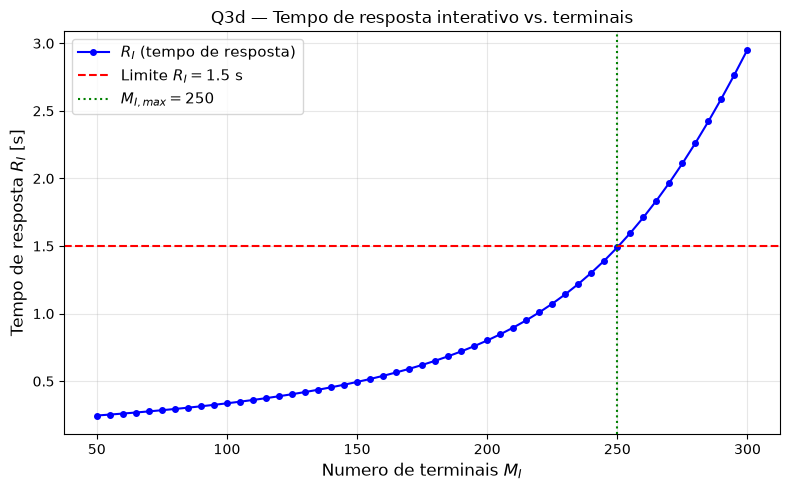

In [12]:
# 3d: varredura M_I = 50..300  (lambda_Q=5.85, CPU 2x mais rapida)
# Nota: pfqn_mvamx usa o fatorial exato para o calculo da constante de normalizacao,
# o que causa overflow numerico para M_I >= 180 (factorial(180) excede float64).
# Para a varredura com populacoes grandes, usa-se amva_mixed (Bard-Schweitzer),
# que e o algoritmo adequado precisamente nestas situacoes de alta populacao.
M_range  = np.arange(50, 301, 5)
R_I_vals = []

for m in M_range:
    N_sw = np.array([np.inf, 3.0, float(m)])
    XN_s, _, _, CN_s, _ = amva_mixed(lam3b, L3_fastCPU, N_sw, Z3, tol=1e-4)
    x_I = float(np.ravel(XN_s)[2])
    R_I_vals.append(float(m / x_I - Z3[2]))

R_I_vals = np.array(R_I_vals)

# Maximo M_I com R_I < 1.5 s
threshold = 1.5
mask  = R_I_vals < threshold
M_max = int(M_range[mask][-1]) if mask.any() else 0
print(f"Maximo de terminais com R_I < {threshold} s:  M_I_max = {M_max}")

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(M_range, R_I_vals, 'b-o', markersize=4, label='$R_I$ (tempo de resposta)')
ax.axhline(threshold, color='r', linestyle='--', linewidth=1.5,
           label=f'Limite $R_I = {threshold}$ s')
if mask.any():
    ax.axvline(M_max, color='g', linestyle=':', linewidth=1.5,
               label=f'$M_{{I,max}} = {M_max}$')
ax.set_xlabel('Numero de terminais $M_I$', fontsize=12)
ax.set_ylabel('Tempo de resposta $R_I$ [s]', fontsize=12)
ax.set_title('Q3d — Tempo de resposta interativo vs. terminais', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('q3d_response_vs_terminals.png', dpi=120, bbox_inches='tight')
plt.show()
